# Gini Impurity as Expected Brier Score

---

## Intuition: What Gini Impurity Measures

Gini impurity measures how **mixed** the labels are in a node.

Imagine this random experiment at a decision tree node:

1. Randomly pick a sample from the node.
2. Randomly assign it a label — but you assign labels according to the node's class distribution, so you pick class $i$ with probability $p_i$.

**Gini impurity is the probability that this randomly assigned label does not match the sample's true label.**

- If the node is **pure** (all samples same class), mislabel probability is small → Gini close to $0$.
- If the node is **fully mixed**, mislabel probability is large → Gini close to its maximum.

This is not a heuristic. It is a clean probabilistic quantity.

---

## Formal Definition of Gini Impurity

Consider a node with $K$ classes. Let

$$p_1,\ p_2,\ \dots,\ p_K$$

be the class probabilities in that node, where

$$p_i \ge 0 \quad \text{for all } i, \qquad \sum_{i=1}^{K} p_i = 1.$$

The **Gini impurity** $G$ of this node is defined as

$$\boxed{G = 1 - \sum_{i=1}^{K} p_i^{2}}$$

**What each term means:**

| Symbol | Meaning |
|--------|---------|
| $K$ | Number of classes |
| $p_i$ | Fraction of samples in this node that belong to class $i$ |
| $\sum p_i^2$ | Sum of squared class probabilities |

An equivalent expression is

$$G = \sum_{i=1}^{K} p_i\,(1 - p_i)$$

Here $p_i(1-p_i)$ is the probability you pick a sample of class $i$ **and** assign it a wrong label under the random labeling experiment.

### Algebraic Proof: Both Forms Are Equal

Start from

$$G = \sum_{i=1}^{K} p_i\,(1 - p_i)$$

Distribute $p_i$ inside:

$$G = \sum_{i=1}^{K} \left( p_i - p_i^{2} \right)$$

Split into two sums:

$$G = \sum_{i=1}^{K} p_i \;-\; \sum_{i=1}^{K} p_i^{2}$$

Use the fact that probabilities sum to $1$:

$$\sum_{i=1}^{K} p_i = 1$$

Therefore:

$$G = 1 - \sum_{i=1}^{K} p_i^{2} \quad \checkmark$$

Both forms are identical.

---

## The Brier Score Connection

### Definition: Brier Score (Multiclass)

For a single prediction in a $K$-class problem, let:

- $\mathbf{q} = (q_1, q_2, \dots, q_K)$ be the predicted probability distribution, with $\sum_{i=1}^{K} q_i = 1$.
- $\mathbf{y} = (y_1, y_2, \dots, y_K)$ be the **one-hot** true label vector:

$$y_i = \begin{cases} 1 & \text{if } i \text{ is the true class} \\ 0 & \text{otherwise} \end{cases}$$

The **Brier Score** for this prediction is

$$\text{Brier}(\mathbf{q},\, \mathbf{y}) = \sum_{i=1}^{K} (q_i - y_i)^{2}$$

This is a squared error on the probability vector. It penalizes probability mass placed away from the true class.

---

### Node Model Setup

At a fixed decision tree node, the empirical class distribution is $\mathbf{p} = (p_1, p_2, \dots, p_K)$.

Consider the simple **node model** that always predicts $\mathbf{q} = \mathbf{p}$ for every sample in this node.

For a sample whose true class is $j$, the one-hot vector has $y_j = 1$ and $y_i = 0$ for $i \ne j$.

The Brier Score for this sample is

$$\text{Brier}_j = \sum_{i=1}^{K} (p_i - y_i)^{2}$$

Separate the $i = j$ term from the rest:

$$\text{Brier}_j = (p_j - 1)^{2} + \sum_{i \ne j} (p_i - 0)^{2}$$

$$\text{Brier}_j = (1 - p_j)^{2} + \sum_{i \ne j} p_i^{2}$$

---

### Expected Brier Score Over the Node Distribution

The true class $j$ is random with $\mathbb{P}(Y = j) = p_j$.

The **expected Brier Score** at this node is

$$\mathbb{E}[\text{Brier}] = \sum_{j=1}^{K} p_j \cdot \text{Brier}_j$$

Substitute the expression for $\text{Brier}_j$:

$$\mathbb{E}[\text{Brier}] = \sum_{j=1}^{K} p_j \left[ (1 - p_j)^{2} + \sum_{i \ne j} p_i^{2} \right]$$

Split into two parts:

$$\mathbb{E}[\text{Brier}] = \underbrace{\sum_{j=1}^{K} p_j\,(1 - p_j)^{2}}_{(A)} \;+\; \underbrace{\sum_{j=1}^{K} p_j \sum_{i \ne j} p_i^{2}}_{(B)}$$

---

#### Simplify Term (A)

Expand the square:

$$(1 - p_j)^{2} = 1 - 2p_j + p_j^{2}$$

Multiply by $p_j$:

$$p_j(1 - p_j)^{2} = p_j - 2p_j^{2} + p_j^{3}$$

Therefore:

$$(A) = \sum_{j=1}^{K} \left( p_j - 2p_j^{2} + p_j^{3} \right)$$

---

#### Simplify Term (B)

$$( B) = \sum_{j=1}^{K} p_j \sum_{i \ne j} p_i^{2}$$

Swap summation order. For a fixed $i$, the term $p_i^2$ appears whenever $j \ne i$, and

$$\sum_{j \ne i} p_j = 1 - p_i$$

So:

$$(B) = \sum_{i=1}^{K} p_i^{2}\,(1 - p_i) = \sum_{i=1}^{K} \left( p_i^{2} - p_i^{3} \right)$$

---

#### Combine (A) and (B)

$$\mathbb{E}[\text{Brier}] = \sum_{i=1}^{K}\left(p_i - 2p_i^{2} + p_i^{3}\right) + \sum_{i=1}^{K}\left(p_i^{2} - p_i^{3}\right)$$

Collect like powers:

- $p_i$ terms: $\sum p_i$
- $p_i^2$ terms: $-2p_i^2 + p_i^2 = -p_i^2$
- $p_i^3$ terms: $p_i^3 - p_i^3 = 0$

So:

$$\mathbb{E}[\text{Brier}] = \sum_{i=1}^{K} p_i \;-\; \sum_{i=1}^{K} p_i^{2}$$

Using $\sum_{i=1}^{K} p_i = 1$:

$$\mathbb{E}[\text{Brier}] = 1 - \sum_{i=1}^{K} p_i^{2}$$

But this is exactly Gini impurity. Therefore:

$$\boxed{\mathbb{E}[\text{Brier}] = G}$$

**Gini impurity is the expected Brier Score at the node when the prediction is the node's own class distribution $\mathbf{p}$.** This is not a coincidence — it is a direct algebraic identity that gives Gini a rigorous probabilistic loss interpretation.

---

## Properties of Gini Impurity

### Gini Is 0 for a Pure Node

A pure node has $p_k = 1$ for some class $k$, and $p_i = 0$ for all $i \ne k$. Then:

$$G = 1 - \left(1^{2} + 0^{2} + \cdots + 0^{2}\right) = 1 - 1 = 0$$

A pure node always has $G = 0$.

---

### Gini Is Maximum at the Uniform Distribution

At the uniform distribution $p_i = \tfrac{1}{K}$ for all $i$:

$$G_{\text{uniform}} = 1 - \sum_{i=1}^{K} \left(\frac{1}{K}\right)^{2} = 1 - K \cdot \frac{1}{K^{2}} = 1 - \frac{1}{K}$$

Maximizing $G$ is equivalent to minimizing $\sum p_i^2$ subject to $\sum p_i = 1,\ p_i \ge 0$. The sum of squares is minimized by the uniform distribution. So:

$$G_{\min} = 0 \quad \text{(pure node)}, \qquad G_{\max} = 1 - \frac{1}{K} \quad \text{(uniform distribution)}$$

---

### Binary Case: Maximum is 0.5 at $p = 0.5$

For $K = 2$, let $p$ be the probability of class 1 and $1 - p$ of class 2:

$$G(p) = 1 - \left(p^{2} + (1-p)^{2}\right)$$

Expand:

$$G(p) = 1 - \left(p^{2} + 1 - 2p + p^{2}\right) = 1 - \left(2p^{2} - 2p + 1\right)$$

$$G(p) = 2p - 2p^{2}$$

Factor:

$$\boxed{G(p) = 2p(1-p)}$$

This is a concave quadratic symmetric around $p = 0.5$. The maximum is at $p = 0.5$:

$$G(0.5) = 2 \times 0.5 \times 0.5 = 0.5$$

So in the binary case: $0 \le G(p) \le 0.5$.

---

### Plot: Gini vs Entropy

For binary classification, define:

- Gini: $G(p) = 2p(1-p)$
- Entropy (base 2): $H(p) = -p\log_2 p - (1-p)\log_2(1-p)$

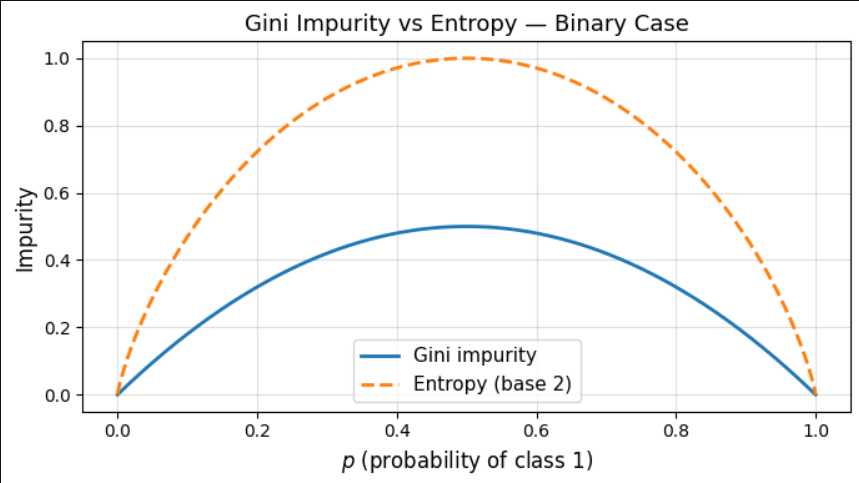

Both curves are:
- Symmetric around $p = 0.5$
- Zero at $p = 0$ and $p = 1$
- Maximum at $p = 0.5$

Entropy is slightly more peaked; its maximum is $1$ bit vs Gini's maximum of $0.5$.

---

## Gini vs Entropy: Side-by-Side

### Formulas

**Gini impurity:**

$$G = 1 - \sum_{i=1}^{K} p_i^{2} = \sum_{i=1}^{K} p_i(1 - p_i)$$

**Entropy (base 2):**

$$H = -\sum_{i=1}^{K} p_i \log_2 p_i \qquad \text{with convention: } 0\log 0 = 0$$

### Ranges

$$0 \le G \le 1 - \frac{1}{K}, \qquad 0 \le H \le \log_2 K$$

Both achieve their maximum at the uniform distribution $p_i = \tfrac{1}{K}$.

### Comparison Table

| Aspect | Gini Impurity | Entropy |
|---|---|---|
| Formula | $1 - \sum p_i^2$ | $-\sum p_i \log_2 p_i$ |
| Range ($K$ classes) | $[0,\ 1 - 1/K]$ | $[0,\ \log_2 K]$ |
| Binary max | $0.5$ at $p = 0.5$ | $1.0$ at $p = 0.5$ |
| Pure node | $G = 0$ | $H = 0$ |
| Operations needed | Multiply, add | Multiply, add, **log** |
| Speed | Faster | Slower |
| Practical splits | Near-identical | Near-identical |

### Why Do They Almost Always Pick the Same Split?

Both measures are:
- Symmetric, concave functions of $\mathbf{p}$.
- Minimized at pure distributions and maximized at the uniform.
- Monotone functions of each other in most of the $[0,1]$ range.

Because of this, the ranking of candidate splits by Gini and by Entropy is nearly always the same, leading to the same or nearly the same tree structure in practice.

---

## Which Does CART Use, and Why?

The original **CART (Classification and Regression Trees)** algorithm — introduced by Breiman, Friedman, Olshen, and Stone (1984) — uses **Gini impurity** by default for classification.

**Reasons:**

**1. Speed — no logarithm required**

$$G = 1 - \sum_{i=1}^{K} p_i^{2}$$

This only requires squaring and summing. No $\log$ calls. When evaluating thousands of candidate splits across many features and nodes, this difference adds up.

**2. Theoretical grounding via Brier Score**

As derived above:

$$G = \mathbb{E}[\text{Brier}]$$

Gini is the expected squared probability loss (Brier Score) of the node's own class distribution predictor. This connects Gini to a proper scoring rule and gives it a rigorous probabilistic justification — it is not just a heuristic.

**3. Comparable performance to Entropy**

In practice, Gini and Entropy produce nearly identical split choices and tree structures. Since their empirical performance is comparable, the computationally cheaper measure — Gini — is the natural default.

> **Summary:** CART uses Gini by default because it is fast to compute (no logs), theoretically grounded through its equivalence to the expected Brier Score, and practically equivalent to Entropy in terms of the splits it selects.